# High level map segmentation
The goal is to convert the pathfinding algorithm into a two level search through new map representations.

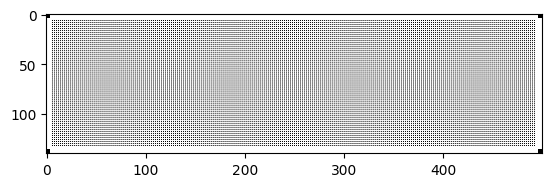

In [39]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DOMAIN = 'warehouse'
MAP = 'sortation_large.map'
maps_path = Path(f'../example_problems/{DOMAIN}.domain/maps/')
map_path = maps_path / MAP
with map_path.open() as f:
    lines = f.readlines()
lines = [line.strip() for line in lines if line.strip()]
lines = lines[4:] # ignore headers

map_ = np.array([list(line) for line in lines])
map_ = np.where(map_ == '@', 1, 0).astype(np.bool)
h, w = map_.shape

plt.imshow(1 - map_, cmap='gray')

In [40]:
from py_floor_plan_segmenter.modules import do_segment
import yaml
with open('py_floor_plan_segmenter/default.yml', 'r') as f:
    config = yaml.safe_load(f)

# Remap bool for compatibility
np.bool = np.bool_
np.bool8 = np.bool_

In [41]:
from skimage import color

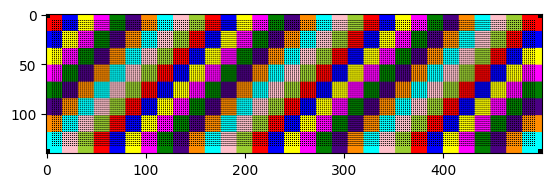

In [42]:
import numpy as np
from skimage.morphology import remove_small_objects

def segment_map_into_grid(map_, n_clusters_x=5, n_clusters_y=5):
    """
    Segment map's interior space into a grid.
    
    Parameters:
    - map_: Binary 2D numpy array
    - n_clusters_x: Number of horizontal grid segments
    - n_clusters_y: Number of vertical grid segments
    
    Returns:
    - Labeled interior segmentation map
    """
    # Invert map to get interior space
    interior = 1 - map_
    
    # Remove small noise objects
    interior = remove_small_objects(interior.astype(bool), min_size=10)
    
    # Get map dimensions
    height, width = interior.shape
    
    # Create segmentation
    segmentation = np.zeros_like(interior, dtype=np.uint8)
    
    # Compute grid cell sizes
    x_step = width // n_clusters_x
    y_step = height // n_clusters_y
    
    # Assign labels based on grid
    for y in range(n_clusters_y):
        for x in range(n_clusters_x):
            # Compute grid region
            x_start = x * x_step
            x_end = (x + 1) * x_step if x < n_clusters_x - 1 else width
            y_start = y * y_step
            y_end = (y + 1) * y_step if y < n_clusters_y - 1 else height
            
            # Create grid-based label
            label = y * n_clusters_x + x + 1
            
            # Mask grid region
            grid_region = interior[y_start:y_end, x_start:x_end]
            
            # Only assign label to interior regions
            if np.any(grid_region):
                segmentation[y_start:y_end, x_start:x_end][grid_region] = label
    
    return segmentation

clusters_x = map_.shape[1] // 2**4
clusters_y = map_.shape[0] // 2**4
segmentation = segment_map_into_grid(map_, n_clusters_x=clusters_x, n_clusters_y=clusters_y)
plt.imshow(color.label2rgb(segmentation))

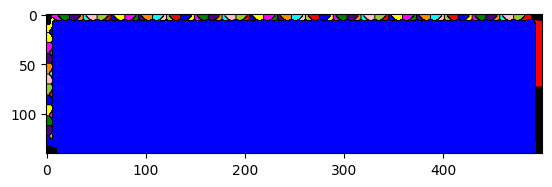

In [25]:
# Generate an initial segmentation, based on py_floor_plan_segmenter
# but without preprocessing (not needed) and merging (not desired)
segmentation = do_segment(map_.astype(np.float32), **config)
# Remove border label
segmentation[segmentation == 255] = 0
plt.imshow(color.label2rgb(segmentation))

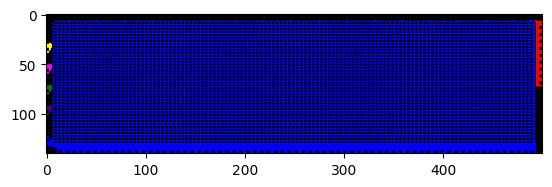

In [26]:
# Identify labels that are not useful and remove them
segmentation *= (map_ == 0)
labels, counts = np.unique(segmentation, return_counts=True)
labels = labels[1:] # ignore 0
counts = counts[1:] # ignore 0
valid_counts = (counts / counts.sum()) >= 0.001
valid_labels = labels[valid_counts]
valid_labels
segmentation[~np.isin(segmentation, valid_labels)] = 0
plt.imshow(color.label2rgb(segmentation))

## Fixing the segmentation
Segmentations generated using this method usually eliminate some pixels which we need for our task. We can recover those pixels through a voting system, such that unlabeled pixels are assigned the label that is most representative of its surroundings

In [43]:
missed_pixels = ((segmentation == 0) + (segmentation == 255)) * (map_ == 0)

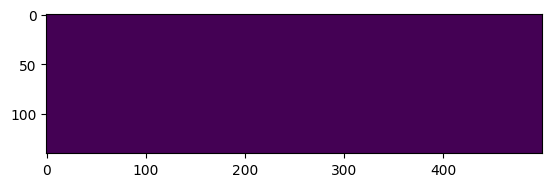

In [44]:
plt.imshow(missed_pixels)

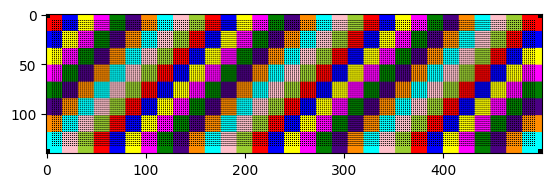

In [45]:
import numpy as np
from scipy.ndimage import label as scipy_label

def detect_disjoint_label_sections(segmentation):
    """
    Identify and correct labels that appear in disjoint sections.
    
    Parameters:
    - segmentation: 2D numpy array of labeled segments
    
    Returns:
    - Corrected segmentation
    - Dictionary of disjoint label sections
    """
    # Remove background labels
    valid_labels = np.unique(segmentation)
    valid_labels = valid_labels[(valid_labels != 0) & (valid_labels != 255)]
    
    disjoint_sections = {}
    corrected_segmentation = segmentation.copy()
    
    for label in valid_labels:
        # Create binary mask for current label
        label_mask = (segmentation == label)
        
        # Find connected components
        labeled_components, num_components = scipy_label(label_mask)
        
        if num_components > 1:
            # Track disjoint sections
            disjoint_sections[label] = num_components
            
            # Keep only the largest component
            largest_component_label = np.argmax(
                [np.sum(labeled_components == i) for i in range(1, num_components + 1)]
            ) + 1
            
            # Correct segmentation to keep only largest component
            corrected_mask = (labeled_components == largest_component_label)
            corrected_segmentation[label_mask] = 0
            corrected_segmentation[corrected_mask] = label
    
    return corrected_segmentation, disjoint_sections

corrected_segmentation, disjoint_sections = detect_disjoint_label_sections(segmentation)
plt.imshow(color.label2rgb(corrected_segmentation))

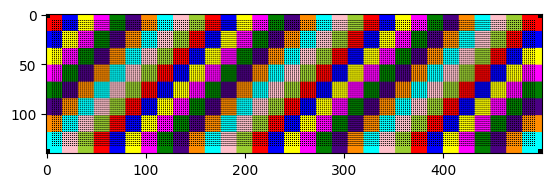

In [46]:
import numpy as np
from scipy.ndimage import maximum_filter

def label_missed_pixels(map_, segmentation, k=3, max_iters=100000):
    """
    Label missed pixels using neighbor voting with kernel size k.
    
    Parameters:
    - map_: Original binary map
    - segmentation: Segmentation map to be filled
    - k: Kernel size for neighborhood (must be odd)
    
    Returns:
    - Fully labeled segmentation map
    """
    # Ensure k is odd
    if k % 2 == 0:
        raise ValueError("Kernel size must be odd")
    
    # Pad maps to handle edge cases
    pad_width = k // 2
    map_padded = np.pad(map_, pad_width, mode='constant', constant_values=0)
    seg_padded = np.pad(segmentation, pad_width, mode='constant', constant_values=0)
    
    # Find missed pixels
    missed_pixels = ((seg_padded == 0) + (seg_padded == 255)) * (map_padded == 0)
    
    # Continue until no missed pixels remain
    iters = 0
    while np.any(missed_pixels) and iters < max_iters:
        # Create a working copy of the segmentation
        new_seg = seg_padded.copy()
        
        # Find coordinates of missed pixels
        missed_coords = np.argwhere(missed_pixels)
        
        for y, x in missed_coords:
            # Extract neighborhood
            neighborhood = seg_padded[
                y - pad_width:y + pad_width + 1, 
                x - pad_width:x + pad_width + 1
            ]
            
            # Remove 0 and 255 labels
            valid_labels = neighborhood[
                (neighborhood != 0) & (neighborhood != 255)
            ]
            
            # If valid labels exist, use mode (most frequent)
            if valid_labels.size > 0:
                unique_labels, counts = np.unique(valid_labels, return_counts=True)
                new_label = unique_labels[np.argmax(counts)]
                new_seg[y, x] = new_label
        
        # Update segmentation and missed pixels
        seg_padded = new_seg
        missed_pixels = ((seg_padded == 0) + (seg_padded == 255)) * (map_padded == 0)
        iters += 1
    
    # Remove padding and return
    return seg_padded[pad_width:-pad_width, pad_width:-pad_width]

# Example usage
# map_ = np.your_binary_map
# segmentation = np.your_initial_segmentation
# labeled_segmentation = label_missed_pixels(map_, segmentation)
labeled_segmentation = label_missed_pixels(map_, segmentation, k=3, max_iters=500)
# Add back walls removed by segmentation process


plt.imshow(color.label2rgb(labeled_segmentation))

## Construct the connectivity graph
The segmentation map helps us identify which tile belongs to which segment, but in order to take advantage of the segmentation we need to constuct a connectivity graph. This graph would store which segments connect to each other, as well as the average cost, which we can estimate as the total static cost computed previously. With this, an algorithm like A* can find the approximate optimal high-level plan.

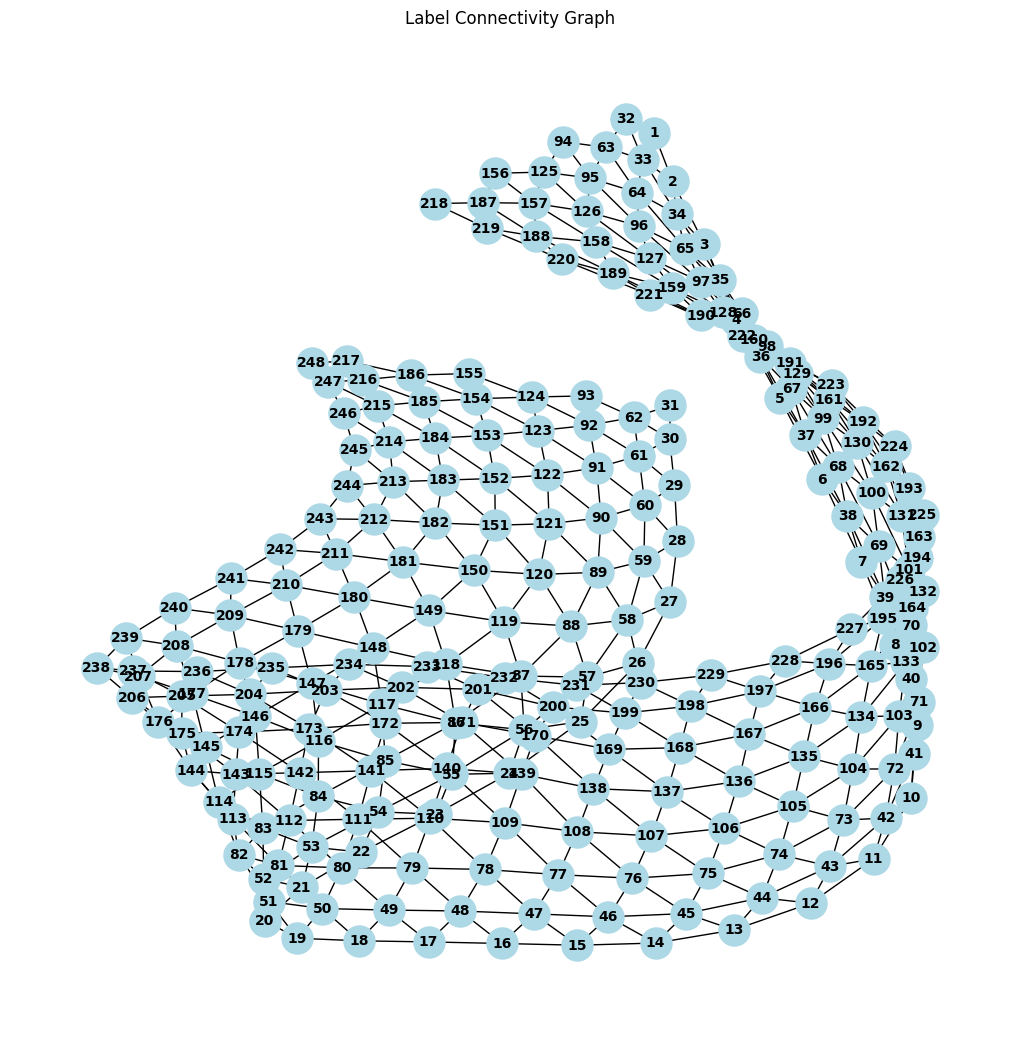

In [47]:
import numpy as np
import networkx as nx
from scipy.ndimage import binary_dilation

def construct_label_connectivity_graph(segmentation, dilation_iterations=2):
    """
    Construct a robust graph showing connectivity between unique labels.
    
    Parameters:
    - segmentation: 2D numpy array of labeled segments
    - dilation_iterations: Number of dilation iterations to detect connections
    
    Returns:
    - NetworkX graph where nodes are unique labels
    """
    # Remove background/border labels
    unique_labels = np.unique(segmentation)
    unique_labels = unique_labels[(unique_labels != 0) & (unique_labels != 255)]
    
    # Create graph
    G = nx.Graph()
    G.add_nodes_from(unique_labels)
    
    # Connectivity matrix to track connections
    connectivity_matrix = np.zeros((len(unique_labels), len(unique_labels)), dtype=bool)
    
    # Detect label connections
    for i, label in enumerate(unique_labels):
        # Create binary mask for current label
        label_mask = (segmentation == label)
        
        # Dilate mask to find neighboring pixels
        dilated_mask = binary_dilation(label_mask, iterations=dilation_iterations)
        
        # Find unique neighboring labels
        neighboring_pixels = segmentation[dilated_mask]
        neighbors = np.unique(neighboring_pixels)
        neighbors = neighbors[(neighbors != 0) & (neighbors != 255) & (neighbors != label)]
        
        # Update connectivity matrix and graph
        for neighbor in neighbors:
            neighbor_index = np.where(unique_labels == neighbor)[0][0]
            if not connectivity_matrix[i, neighbor_index]:
                G.add_edge(label, neighbor)
                connectivity_matrix[i, neighbor_index] = True
                connectivity_matrix[neighbor_index, i] = True
    
    return G

# Optional visualization
def visualize_connectivity_graph(G):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=500, font_size=10, font_weight='bold')
    plt.title('Label Connectivity Graph')
    plt.show()

# Example usage
G = construct_label_connectivity_graph(labeled_segmentation)
visualize_connectivity_graph(G)
print()

In [48]:
static_cost = np.nan_to_num(np.load(f'../python/static_costs/{MAP}_costs.npy'), posinf=0)
static_cost = np.clip(static_cost, 0, np.quantile(static_cost, 0.99))

In [49]:
label = 20
label_map = (labeled_segmentation == label)
label_area = label_map.sum()
avg_static_cost = (static_cost * label_map).sum() / label_area
avg_static_cost

np.float64(1.6070096152169364)

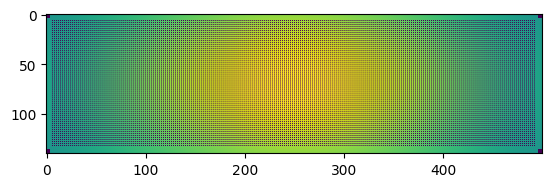

In [50]:
plt.imshow(static_cost)

In [51]:
def graph_to_connectivity_dict(G, segmentation, static_cost):
    """
    Convert graph to connectivity dict with area and static cost properties.
    
    Parameters:
    - G: NetworkX graph of label connectivity
    - segmentation: Original segmentation map
    - static_cost: Static cost map corresponding to segmentation
    
    Returns:
    - Dictionary of label connections with costs
    """
    # Compute label properties
    label_properties = {}
    for label in np.unique(segmentation):
        if label not in [0, 255]:
            # Create label mask
            label_map = (segmentation == label)
            
            # Compute label area
            label_area = label_map.sum()
            
            # Compute average static cost
            avg_static_cost = (static_cost * label_map).sum() / label_area
            
            # Store properties
            label_properties[label] = {
                'area': label_area,
                'avg_static_cost': avg_static_cost
            }
    
    # Create connectivity dictionary with costs
    connectivity_dict = {}
    
    for node in G.nodes():
        # Get connected nodes
        connected_nodes = list(G.neighbors(node))
        
        # Compute connection costs
        connection_costs = {}
        for neighbor in connected_nodes:
            # Cost based on area difference and static costs
            area_diff_cost = abs(
                label_properties[node]['area'] - label_properties[neighbor]['area']
            ) / max(label_properties[node]['area'], label_properties[neighbor]['area'])
            
            static_cost_diff = abs(
                label_properties[node]['avg_static_cost'] - 
                label_properties[neighbor]['avg_static_cost']
            )
            
            # Combined cost (you can adjust weights)
            combined_cost = area_diff_cost + static_cost_diff
            
            connection_costs[int(neighbor)] = float(combined_cost)
        
        connectivity_dict[int(node)] = connection_costs
    
    return connectivity_dict

# Example usage
connectivity_dict = graph_to_connectivity_dict(G, labeled_segmentation, static_cost)

In [52]:
connectivity_dict

{1: {2: 0.05992772998158745, 32: 0.06841143100844438, 33: 0.18231056660028278},
 2: {1: 0.05992772998158745,
  3: 0.05455003465924957,
  33: 0.12301494787027559,
  34: 0.18298873796567808},
 3: {2: 0.05455003465924957,
  4: 0.055671760014125216,
  34: 0.1284387033064285,
  35: 0.18993793215070445},
 4: {3: 0.055671760014125216,
  5: 0.056289945329938584,
  35: 0.13426617213657924,
  36: 0.19675017975188872},
 5: {4: 0.056289945329938584,
  6: 0.056285721915108944,
  36: 0.14046023442195013,
  37: 0.20324486952561596},
 6: {5: 0.056285721915108944,
  7: 0.05553722381591797,
  37: 0.14695914761050702,
  38: 0.20920943165873432},
 7: {6: 0.05553722381591797,
  8: 0.0539267403738839,
  38: 0.15367220784281635,
  39: 0.2144049759749527},
 8: {7: 0.0539267403738839,
  9: 0.05135154724121094,
  39: 0.1604782356010688,
  40: 0.2185746077652815},
 9: {8: 0.05135154724121094,
  10: 0.04773303440638954,
  40: 0.16722306052407057,
  41: 0.22145749186421473},
 10: {9: 0.04773303440638954,
  11: 0.0

In [53]:
import json

np.save(f'../python/high_level_graph/{MAP}_segmentation.npy', labeled_segmentation)
with open(f'../python/high_level_graph/{MAP}_connectivity_graph.json', 'w') as f:
    json.dump(connectivity_dict, f)